<a href="https://colab.research.google.com/github/JBlankenship1/MachineLearningProjects/blob/main/SVM-GaussianKernel-DigitIdentifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS 460G: Machine Learning
## Spring 2026
## Assignment 2

___


**Double click on this cell and write your name/UK ID/email.**

Name: Jacob Blankenship

ID: 912676349

Email: jrblanke2@gmail.com

# READ THIS FIRST

## Reminder on what's up for you in this assignment

This is one of the three assignments. A maximum of 100 points are available from this assignment. You will need to use your learning from the last 3 weeks' lectures (Week 5$-$7).

You will turn in completed version of this notebook (both ipynb and pdf files). Your submission will be graded under 3 major factors:

  * Functional code: Completed code with every piece functional
  * Correctness: Your submitted notebook contains correct code that gives accurate results unless otherwise stated
  * Documentation: Every cell is well-documented and easy-to-follow to reproduce the results

$~$

## Reproducibility in iPython Notebooks

As you have noticed, iPython notebooks are interactive Python sessions that allow us to spread our code, text, and markdown seamlessly.

Every word you read and write is modifiable. You can double click this cell to change the text you're reading now. You will use such cells to write your answers/code.

Don't forget to double click the first cell, and write your name, ID, and email.

Cells can be added for code or text. Check the top left corner: "+Code" to add a new cell for writing code and "+Text" to add a new cell for raw texts.

The best thing about notebooks is that you can quickly run small components of your code in separate cell to make sure they work before putting together for a larger component. Another good thing is, as you noticed during our in-class hands-on, the entire assignment self-contained in this ipynb file. So, you can put all your functions and classes into the cells of this notebook. Please make sure your code is written cleanly with documentation (how to use your work once completed, to reproduce the exact same results). Particularly, pay attention to setting random_state (where applicable) to ensure reproducibility of your results. Once you're done, download the notebook as ipynb file and submit on Canvas before the due date. Please also make sure to download the PDF file when everything works fine: File-->Print-->Save as PDF

Please be reminded, it is important to write readable and reproducible code. Let's take a small fine step towards that goal, with this notebook.

## **Digit Image Classification using SVM and PCA**

---

This assignment is focused on three objectives:
  1. Perform PCA to reduce data dimensionality and select top k most relevant features via 3-way holdout and cross-validation.
  2. Apply linear SVM (soft-margin) with 3-way holdout validation and cross-validation for selecting optimal C.  
  3. Apply non-linear SVM (Gaussian Kernel) with 3-way holdout validation and cross-validation for selecting the optimal $C$ and $\gamma$ values.

### Dataset exploration

 * Load the MNIST digit image datasets from PyTorch using the following line
      `trainset = torchvision.datasets.MNIST(root = "./data", train = True, download=True)`     
      
      - For loading test set, just set `train=False`

In [44]:
import torch
from torchvision import datasets
import numpy as np
trainset = datasets.MNIST('./data', train=True, download=True)
classes = ('0', '1', '2', '3', '4', '5',
           '6', '7', '8', '9')

#Initialize an empty list for images and another one for labels
X_train = []
y_train = []

#Get the training images and their corresponding labels
for k, (image, label) in enumerate(trainset):
    X_train.append(image)
    y_train.append(label)

#reshape image and label arrays
X_train = np.reshape(X_train, [-1, 28*28])
y_train = np.reshape(y_train, [-1])

#Verify shape
X_train.shape, y_train.shape

((60000, 784), (60000,))

In [45]:
'''To Do: Import necessary packages here'''
#add your code here

from matplotlib import colormaps
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


#### Read the data

---


#### Understand it: check, analyze, visualize

#### Train data

In [97]:
'''Train data from the MNIST dataset'''
#add your code her
trainset = datasets.MNIST('./data', train=True, download=False)


In [106]:
'''Initialize an empty list for images and another one for labels'''

X_train = []
y_train = []

'''Get the training images and their corresponding labels'''

for k, (image, label) in enumerate(trainset):
    X_train.append(image)
    y_train.append(label)

'''reshape image and label arrays'''

X_train = np.reshape(X_train, [-1, 28*28])
y_train = np.reshape(y_train, [-1])


'''Verify shape: (60000, 784) and (60000,)'''
X_train.shape, y_train.shape, X_train[1]

((60000, 784),
 (60000,),
 array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  51, 159, 253,
        159,  50,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  48, 238,
        252, 252, 252, 237,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   

#### Visualize one train image from each class in subplots
    - The subplots are in a single row
    - Print the class labels as the title of each subplot
    - The images should be shown using 'gray' color map

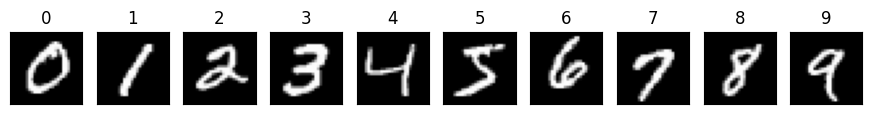

In [107]:
'''Visualize the digit images in a single row'''

digitnum = 0
digitarr = []
for i in range(0,10):
  digitarr.append(np.where(y_test == i)[0][0])
#https://stackoverflow.com/questions/18079029/index-of-element-in-numpy-array#18079151

fig = plt.figure(figsize=(11, 1))
for k in range(len(digitarr)):
  temparr = X_train[digitarr[k]].reshape(28,28)
  fig.add_subplot(1,10,k+1)
  plt.title('%i' %y_train[digitarr[k]])
  plt.xticks(())
  plt.yticks(())
  plt.imshow(temparr,cmap='gray', vmin=0, vmax=255)
plt.show()


#### Load Test data

Now, repeat the above steps to load the testset, create X_test and y_test arrays, and visualize 10 gray colormap digit images in a single row

In [104]:
'''load test data'''
#add your code here
testset = datasets.MNIST('./data', train=False, download=False)

for k, (image, label) in enumerate(trainset):
    X_test.append(image)
    y_test.append(label)

'''reshape image and label arrays'''

X_test = np.reshape(X_test, [-1, 28*28])
y_test = np.reshape(y_test, [-1])


'''Verify shape: (60000, 784) and (60000,)'''
X_test.shape, y_test.shape, X_test[1]

In [ ]:
'''Initialize an empty list for images and another one for labels'''
#add your code here

'''Get the testing images and their corresponding labels'''
#add your code here

'''reshape image and label arrays'''
#add your code here

'''Verify shape: (10000, 784) and (10000,)'''
#add your code here

'Verify shape: (10000, 784) and (10000,)'

In [ ]:
'''Visualize the digit images of 10 classes in a single row'''
#add your code here

'Visualize the digit images of 10 classes in a single row'

### Perform PCA: Select top k features

- Use only the numpy package
- Find the top k principal components that can explain at least 90% variance
- Visualize the top k principal components cumulative percentage of explained variance

In [ ]:
'''First standardize the data: normalize to 0-1'''
#add your code here

'First standardize the data: normalize to 0-1'

In [ ]:
'''Principal Components using numpy'''
#add your code here

'Principal Components using numpy'

In [ ]:
'''Plot the top k principal components explaining >90% variance'''
#add your code here

'Plot the top k principal components explaining >90% variance'

In [ ]:
'''Sort the eigen values in descending order and the corresponding eigen vectors'''
#add your code here

'Sort the eigen values in descending order and the corresponding eigen vectors'

In [ ]:
'''Select the top k PCs, perform reshape as you might find it necessary'''
#add your code here

'Select the top k PCs, perform reshape as you might find it necessary'

### PCA on Test data
Now, repeat the above steps to perform feature selection on the test data

In [ ]:
'''Select the top k PCs, perform reshape as you might find it necessary'''
#add your code here

'Select the top k PCs, perform reshape as you might find it necessary'

In [ ]:
'''Plot the first two features for the train and test data after PCA transformation'''

# Linear SVM with 3-way holdout and cross-validation model selection (30 points)

In [ ]:
'''
We will create the three subsets: train, test, and
validation for the 3-way holdout validation with stratification on class labels.
We already have train and test sets.

To Do: Split the training data set in the following proportions:
90% for training, 10% for validation
'''

#add your code here

'\nWe will create the three subsets: train, test, and\nvalidation for the 3-way holdout validation with stratification on class labels\n\nTo Do: Split the training data set in the following proportions:\n90% for training, 10% for validation\n'

In [ ]:
'''To Do: Check the label distribution for train, validation, and test sets'''
#add your code here

'To Do: Check the label distribution for train, validation, and test sets'

In [ ]:
'''
To Do:
1. Get the SVM classifier from scikit-learn
2. train the model on the train set
3. get evaluation (accuracy measure) on the validation set for
different C values
4. Select the best model in terms of validation accuracy.
'''

'''
You can run this cell multiple times to find the best C value.
Try at least 3 different values for C. Just take note of their effects and
keep the best one only.
'''
#add your code here

'\nYou can run this cell multiple times to find the best C value.\nTry at least 3 different values for C. Just take note of their effects and\nkeep the best one only.\n'

In [ ]:
'''To Do: Perform testing and evaluate on the best model'''
#add your code here

'To Do: Perform testing and evaluate on the best model'

## Next, let's explore the Cross-validation of linear SVM
Remember, the test set remains fixed. So, the previous split is still OK. You just need to combine the previous train and validation sets.

In [ ]:
'''
To Do:
Combine the previous train and validation sets
Then verify their shapes'''
#Hint: You can do this using np.concatenate for inputs and labels separately
#add your code here

'\nTo Do:\nCombine the previous train and validation sets\nThen verify their shapes'

### Linear SVM Classifier with K-Fold cross-validation
We will try to find the best C through a 5-fold cross-validation technique.

In [ ]:
'''
To Do:
1. Get KFold and assign n_splits=5 to create 5-fold cross-validation
2. get all 5-folds for the MNIST train set
3. take the same C-values you took for the previous task
4. for each C, train and evaluate
3. get evaluation (average accuracy measure) on the validation set for different C values
4. Select the best model in terms of validation accuracy.
'''
#add your code here

'\nTo Do:\n1. Get KFold and assign n_splits=5 to create 5-fold cross-validation\n2. get all 5-folds for the Breast Cancer Dataset\n3. take the same C-values you took for the previous task\n4. for each C, train and evaluate\n3. get evaluation (average accuracy measure) on the validation set for different C values\n4. Select the best model in terms of validation accuracy.\n'

### Now, we retain the model for the best C-value

You can train only with the best C and then measure the test performance

In [ ]:
'''
Train the SVM model with the best C-value found through the cross-validation.
Then evaluate the model on the test set and compute accuracy

'''
#add your code here

To Do: Add one line discussion on this section (Linear SVM with 3-way holdout vs cross-validation techniques).<br>
(doubel-click here to edit this cell)

# Non-Linear SVM with 3-way holdout and cross-validation model selection (30 points)

****

## First, let's explore the 3-way holdout validation of non-linear SVM with Gaussian kernel

In [ ]:
'''
We will create the three subsets: train, test, and
validation for the 3-way holdout validation with stratification on class labels.
We already have train and test sets.

To Do: Split the training data set in the following proportions:
90% for training, 10% for validation
'''

#add your code here

In [ ]:
'''
To Do:
1. Get the SVM classifier from scikit-learn and define with rbf kernel (with C and Gamma values)
2. train the model on the train set
3. get evaluation (accuracy measure) on the validation set for
different C and Gamma values
4. Select the best model in terms of validation accuracy.
'''

'''
You can run this cell multiple times to find the best C and Gamma values.
Try at least 3 different values for C and Gamma. Just take note of their effects and
keep the best one only.
'''
#add your code here

In [ ]:
'''To Do: Perform testing and evaluate on the best model'''
#add your code here

## Next, let's explore the Cross-validation of the non-linear SVM with Gaussian kernel
Remember, the test set remains fixed. So, the previous split is still OK. You just need to combine the previous train and validation sets.

### Non-Linear SVM Classifier with K-Fold cross-validation
We will try to find the best C and Gamma through a 5-fold cross-validation technique.

In [ ]:
'''
To Do:
1. Get KFold and assign n_splits=5 to create 5-fold cross-validation
2. get all 5-folds for the MNIST train set
3. take the same C-values you took for the previous task
4. for each combination of C and Gamma, train and evaluate
3. get evaluation (average accuracy measure) on the validation set for different C and Gamma values
4. Select the best model in terms of validation accuracy.
'''
#add your code here

### Now, we retain the model for the best C and $\gamma$-values

You can train only with the best C and $\gamma$; then measure the test performance

In [ ]:
'''
Train the Non-Linear SVM model with the best combination of C and Gamma values found through the cross-validation.
Then evaluate the model on the test set and compute accuracy

'''
#add your code here

To Do: Add one line discussion on this section (Non-Linear SVM with 3-way holdout vs cross-validation techniques).<br>
(doubel-click here to edit this cell)

# Final Discussion (5 points)

Based on your experiments above, discuss your findings comparing the approaches having PCA-based preprocessing and model validation techniques. Also add if you faced any challenges while working on this assignment.

# Use of Generative AI (5 points)

**1. Did you get any help from any Generative AI tools (e.g., ChatGPT) for completing this assignment task? Please explain.** (1 points)

Your response:

$~$


**2. What prompts did you use to get assistance from Generative AI? Please list all the prompts that you used.
If you didn't get any Generative AI assistance, simply write the following text to respond this question.** (3 points)
> **I didn't seek any Generative AI assistance to complete this assignment task.**

Your reponse:


$~$


**3. How would you distribute credit between you and the Generative AI tool? Please give the percentage of your contribution and the contribution of Generative AI.** (1 points)

Your reponse:

### Bonus: Discussion with Other Students (5 points)

**Did you have (any level of discussion) with someone else in the class for completing this assignment task? Please explain.** (5 points)

Your response: